## Event-Aware News Timeline & Cost-Efficient RAG System

## Project Overview

This project analyzes large-scale news data to identify major events over time and build a structured knowledge base for intelligent question answering.

Instead of using raw articles directly, we:

- Cluster news into meaningful event groups

- Create year-based timelines

- Generate monthly event summaries

- Build a compact knowledge abstraction layer

- Prepare data for a Retrieval-Augmented Generation (RAG) system

The goal is to design a cost-efficient, scalable LLM pipeline suitable for real-world deployment.

## Problem Statement

Large news datasets contain thousands of articles. Directly feeding all articles into an LLM is:

- Expensive

- Slow

- Token inefficient

- Difficult to manage

We aim to:

- 1. Detect major recurring events.

- 2. Create structured monthly summaries.

- 3. Reduce token usage using abstraction.

- 4. Prepare a lightweight knowledge base for RAG-based Q&A.

In [1]:
import pandas as pd
import numpy as np

#### Dataset Path Confirmation

In [2]:
!ls /kaggle/input

all-the-news-dataset


In [3]:
!ls /kaggle/input/all-the-news-dataset

all-the-news-2-1.csv


#### Required Column Selection

In [4]:
df = pd.read_csv(
    "/kaggle/input/all-the-news-dataset/all-the-news-2-1.csv",
    usecols=["title", "article", "date", "publication"],
    low_memory=False
)

In [5]:
df.shape

(2688879, 4)

In [6]:
df.head()

,date,title,article,publication
0,2016-12-09 18:31:00,We should take concerns about the health of li...,"This post is part of Polyarchy, an independent...",Vox
1,2016-10-07 21:26:46,Colts GM Ryan Grigson says Andrew Luck's contr...,The Indianapolis Colts made Andrew Luck the h...,Business Insider
2,2018-01-26 00:00:00,Trump denies report he ordered Mueller fired,"DAVOS, Switzerland (Reuters) - U.S. President ...",Reuters
3,2019-06-27 00:00:00,France's Sarkozy reveals his 'Passions' but in...,PARIS (Reuters) - Former French president Nico...,Reuters
4,2016-01-27 00:00:00,Paris Hilton: Woman In Black For Uncle Monty's...,Paris Hilton arrived at LAX Wednesday dressed ...,TMZ


### why we don't take entaire 2688879 data?
Processing entire dataset:

- Takes more RAM & long time

- Slower clustering 

- Higher embedding time ---> apro(6-7 hrs)

- More computation cost

For a demo + research-level project, we don’t need all 2.6 lakh articles.

#### Data Sampling Step (25k)
We can take 30k ,50k or The full dataset but:

**Why 25k samples:** "25,000 samples were selected to balance computational efficiency and topic diversity. It is large enough to preserve event structure while reducing embedding and clustering cost compared to the full 2.6 lakh dataset."

**Why Not less 20k,15K?:**
- Miss smaller event clusters

- Reduce topic diversity

- Affect clustering quality

Smaller sample = less event coverage.

In [7]:
df_sample = df.sample(25000, random_state=42)
df_sample.shape

(25000, 4)

In [8]:
df_sample.duplicated().sum()

np.int64(128)

In [9]:
df_sample.isna().sum()

date             0
title            2
article        947
publication    101
dtype: int64

#### Key problems detected:
- Dulpicate values
- Missing article text-->	Breaks embeddings
- Date as string ------->Cannot build timeline
- Text not cleaned ----->	Poor clustering


#### From above info:
- 'articles' (947 missing values) = This means,Some rows have a title and metadata but no article body.

- And also missing values included in title-2 and publication-101

- 'date' (object - Dtype) = Dates are currently strings

## Step 1: Data Cleaning

#### Convert Date object-datetime formation
- In this i found the our date column contains mixed formats by (errors='raise')
- So those mixed formats deals with the (format="mixed") without raising any null values

In [10]:
df_sample["date"] = pd.to_datetime(
    df_sample["date"],
    format="mixed",
    errors="coerce"
)


In [11]:
# remove timezone if created any
df_sample["date"] = df_sample["date"].dt.tz_localize(None)

### Check the basics After Datetime conversion  

In [12]:
df_sample["date"].isna().sum()      # NO null & conversion is good

np.int64(0)

In [13]:
df_sample.duplicated().sum()       # 2 duplicates are raised

np.int64(130)

In [14]:
df_sample.isna().sum()         # Remaining all are same

date             0
title            2
article        947
publication    101
dtype: int64

- Handled mixed ISO and non-ISO datetime formats using pandas’ mixed-format parsing

### Remove The Duplicate Values
##### Important:
- In the "date" column 2 duplictes are shows a negligible impact.
- does not affect timelines ,not affect breaking-news evolution , not affect clustering

Improves data integrity

In [15]:
df_sample = df_sample.drop_duplicates(
    subset=["title", "article", "date", "publication"]
).reset_index(drop=True)

In [16]:
df_sample.duplicated().sum()

np.int64(0)

In [17]:
df_sample.shape

(24870, 4)

In [18]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24870 entries, 0 to 24869
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         24870 non-null  datetime64[ns]
 1   title        24868 non-null  object        
 2   article      24043 non-null  object        
 3   publication  24869 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 777.3+ KB


In [19]:
df_sample.isna().sum()

date             0
title            2
article        827
publication      1
dtype: int64

### Duplicate removal
##### For title 
Empty string:
- won’t break text concatenation , won’t add fake words , won’t affect embeddings much (article text dominates)

##### For publication

It’s metadata, not semantic text

- Empty string is better than:"Unknown" (adds noise), dropping the row (loses data)

In [20]:
# Fill harmless metadata nulls
df_sample[["title", "publication"]] = (
    df_sample[["title", "publication"]].fillna("")
)

### Handle article nulls properly (important)

We have 827 rows without article text.

These rows:

- cannot be embedded meaningfully

- add noise to clustering

- Best practice: drop them

In [21]:
df_sample = df_sample[df_sample["article"].notna()].reset_index(drop=True)

This is only ~3% of whole data — totally acceptable.

### Check once again 

In [22]:
df_sample.duplicated().sum()

np.int64(0)

In [23]:
df_sample.isna().sum()

date           0
title          0
article        0
publication    0
dtype: int64

In [24]:
df_sample.shape

(24043, 4)

In [25]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24043 entries, 0 to 24042
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         24043 non-null  datetime64[ns]
 1   title        24043 non-null  object        
 2   article      24043 non-null  object        
 3   publication  24043 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 751.5+ KB


### Text Cleaning (before vectorization)

- Raw news text = noisy (HTML, symbols, duplicates)

- Phone numbers,addresses,copyright notices → pure noise for event clustering

- HDBSCAN + embeddings work better on clean text

- This directly improves cluster quality

In [26]:
# Article → heavy cleaning (noise, boilerplate, phone numbers)
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)          # remove HTML
    text = re.sub(r"http\S+|www\S+", " ", text) # remove URLs
    text = re.sub(r"\b\d{3}[-\s]?\d{3}[-\s]?\d{4}\b", " ", text)  # remove phone numbers
    text = re.sub(r"[^a-z0-9\s]", " ", text)    # keep letters & nubbers
    text = re.sub(r"\s+", " ", text).strip()    # remove extra spaces
    return text

df_sample["clean_article"] = df_sample["article"].fillna("").apply(clean_text)

In [27]:
df_sample[["article", "clean_article"]].head(2)

,article,clean_article
0,"THINK GERMANY and migration, and you probably ...",think germany and migration and you probably t...
1,Actress Bette Midler was roasted on social med...,actress bette midler was roasted on social med...


In [28]:
df_sample['article'][1]

'Actress Bette Midler was roasted on social media after sharing a fabricated quote pretending to be from President\xa0Trump that called Republicans "the dumbest group of voters in the country." Midler, a staunch critic of President TrumpDonald John TrumpFacebook releases audit on conservative bias claims Harry Reid: \'Decriminalizing border crossings is not something that should be at the top of the list\' Recessions happen when presidents overlook key problems MORE, shared the debunked quote with her 1.6 million followers on Sunday evening. It was retweeted more than 10,000 times and "liked" more than 27,000 times. It contained a picture that appeared to have been taken from a printed publication with the fake Trump quote, along with a caption from Midler that read:\xa0"He certainly knew his crowd." \xa0 He certainly knew his crowd. pic.twitter.com/MHJl12CGsp However, the supposed Trump quote had been fact-checked by Snopes in 2015, which rated it "false."\xa0Midler had not deleted th

In [29]:
df_sample['clean_article'][1]

'actress bette midler was roasted on social media after sharing a fabricated quote pretending to be from president trump that called republicans the dumbest group of voters in the country midler a staunch critic of president trumpdonald john trumpfacebook releases audit on conservative bias claims harry reid decriminalizing border crossings is not something that should be at the top of the list recessions happen when presidents overlook key problems more shared the debunked quote with her 1 6 million followers on sunday evening it was retweeted more than 10 000 times and liked more than 27 000 times it contained a picture that appeared to have been taken from a printed publication with the fake trump quote along with a caption from midler that read he certainly knew his crowd he certainly knew his crowd pic twitter com mhjl12cgsp however the supposed trump quote had been fact checked by snopes in 2015 which rated it false midler had not deleted the tweet as of early monday afternoon re

#### Cleaning the title
Titles are already concise and high-signal. Over-cleaning them can hurt.

In [30]:
# Title → light cleaning only
def clean_title(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_sample["clean_title"] = df_sample["title"].fillna("").apply(clean_title)

#### Now combine [clean_title+clean_article] (this is the input to the embedding model):

In [31]:
# Then combine
df_sample["text_for_embedding"] = (
    df_sample["clean_title"] + ". " +
    df_sample["clean_article"]
)

In [32]:
df_sample.head()

,date,title,article,publication,clean_article,clean_title,text_for_embedding
0,2019-05-16 00:00:00,Germany is cautiously recruiting more workers ...,"THINK GERMANY and migration, and you probably ...",Economist,think germany and migration and you probably t...,germany is cautiously recruiting more workers ...,germany is cautiously recruiting more workers ...
1,2019-06-03 00:00:00,Bette Midler roasted after sharing fake Trump ...,Actress Bette Midler was roasted on social med...,The Hill,actress bette midler was roasted on social med...,bette midler roasted after sharing fake trump ...,bette midler roasted after sharing fake trump ...
2,2017-05-18 00:00:00,Airline industry braces for record-high summer...,The airline industry is bracing for a record-h...,The Hill,the airline industry is bracing for a record h...,airline industry braces for record high summer...,airline industry braces for record high summer...
3,2020-03-17 00:00:00,FedEx suspends 2020 profit outlook; coronaviru...,(Reuters) - U.S. package delivery company FedE...,Reuters,reuters u s package delivery company fedex cor...,fedex suspends 2020 profit outlook coronavirus...,fedex suspends 2020 profit outlook coronavirus...
4,2019-01-26 05:00:05,Washington State Weighs New Option After Death...,SEATTLE — Leslie Christian recently added unus...,The New York Times,seattle leslie christian recently added unusua...,washington state weighs new option after death...,washington state weighs new option after death...


In [33]:
df_sample["text_for_embedding"][0]

'germany is cautiously recruiting more workers from outside the eu opening up a crack. think germany and migration and you probably think refugees but german employers desperate for workers have their eye on a different sort of immigrant after a decade of economic growth unemployment is at its lowest and job vacancies their highest since reunification in 1990 almost two thirds of firms complain about a lack of skilled labour see chart so germany is starting to look outward germany s modest wage growth suggests there is no widespread labour shortage but a tour through the manufacturing heartland of baden w rttemberg unemployment rate 3 1 finds few doubts among employers if you advertise in the newspaper you get zero cries peter kaufmann who runs a house building firm in oberstadion a village near ulm he reckons he could raise his headcount from 100 to 150 if he could find more bricklayers and carpenters services like elderly care and tourism are crying out for workers nicole hoffmeister

In [34]:
df_sample["text_for_embedding"].str.len().describe()

count     24043.000000
mean       3114.833091
std        3446.642234
min          15.000000
25%        1173.000000
50%        2333.000000
75%        4033.000000
max      130741.000000
Name: text_for_embedding, dtype: float64

## Step 2: Text Embedding

Used sentence embedding model to convert articles into numerical vectors.

Purpose:

Capture semantic meaning

Enable clustering

Why NOT TF-IDF ?

- Counts word frequency , Cannot understand meaning , Treats synonyms as different

Fails when articles use different wording for same event

WHY WE CHOOSE SENTENCE EMBEDDINGS ?

- News events are semantically similar even when vocabulary differs. Sentence embeddings capture semantic meaning better than bag-of-words methods like TF-IDF.

In [35]:
from sentence_transformers import SentenceTransformer

embbed_model = SentenceTransformer("all-MiniLM-L6-v2")

2026-03-11 04:22:48.666092: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773202968.870541      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773202968.929025      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773202969.416048      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773202969.416085      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773202969.416088      55 computation_placer.cc:177] computation placer alr

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [36]:
texts = df_sample["text_for_embedding"].tolist()

##### Check embedding output
- One vector per article
- Each vector represents meaning

In [37]:
embeddings = embbed_model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/752 [00:00<?, ?it/s]

In [38]:
embeddings.shape

(24043, 384)

In [39]:
# sanity check

np.isnan(embeddings).sum()

np.int64(0)

In [40]:
len(embeddings[0])

384

In [41]:
np.linalg.norm(embeddings[0])

np.float32(1.0)

SentenceTransformer("all-MiniLM-L6-v2")outputs L2-normalized embeddings by default.
- Each vector is scaled to unit length
- So its Euclidean norm is exactly 1.0

#### Why models do this (important intuition)

##### L2 normalization ensures:

- Cosine similarity = dot product

- Comparisons depend on direction (meaning), not magnitude

- More stable clustering and retrieval

##### This is very good for:

- semantic similarity ,UMAP (with cosine metric) ,clustering pipelines

#### Compare related vs unrelated articles (clarity test)
Cosine similarity measures the angle between two vectors:
- 0.85 – 1.0 -----> Same event / highly similar
- 0.60 – 0.85 ---->	Related topic
- 0.30 – 0.60 ---->	Weakly related
- 0.00 – 0.30 ---->	Mostly unrelated
- < 0.00	-------->Completely unrelated / different topics

In [42]:
# Check for one example
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity(
    embeddings[0].reshape(1, -1),
    embeddings[384].reshape(1, -1)
)

array([[0.26869008]], dtype=float32)

0.26869008 --> Weak semantic relationship

different events , different angles , same broad domain (e.g., politics) but not same story

This is exactly what we want embeddings to reflect.


### Visualize embeddings using PCA
- Embeddings are 384-D → humans can’t see that.
- We reduce them to 2D.


In [45]:
# Reduce embeddings to 2D with PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2,random_state=42)
embeddings_pca = pca.fit_transform(embeddings)
embeddings_pca.shape

(24043, 2)

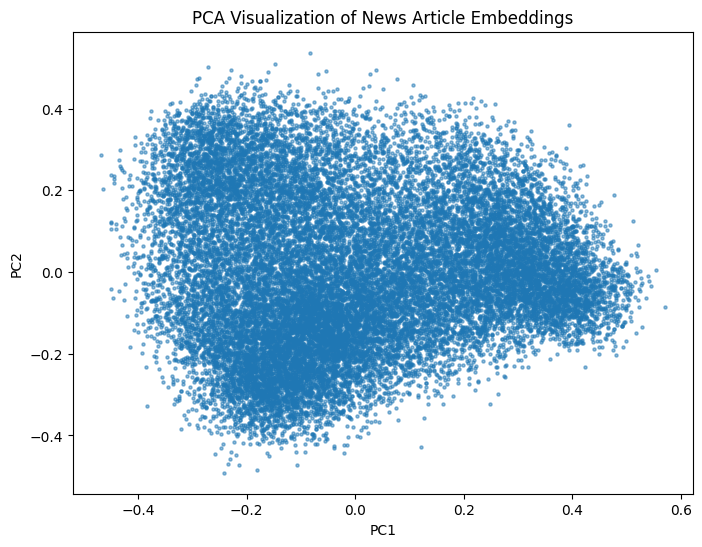

In [46]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

plt.scatter(
    embeddings_pca[:,0],
    embeddings_pca[:,1],
    s=5,
    alpha=0.5
)

plt.title("PCA Visualization of News Article Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

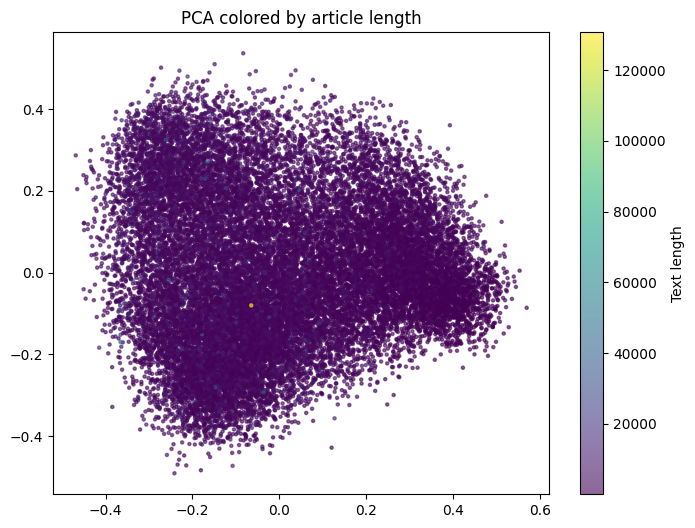

In [47]:
# color by article length (sanity check)
lengths = df_sample["text_for_embedding"].str.len()

plt.figure(figsize=(8, 6))
plt.scatter(
    embeddings_pca[:, 0],
    embeddings_pca[:, 1],
    c=lengths,
    s=5,
    cmap="viridis",
    alpha=0.6
)
plt.colorbar(label="Text length")
plt.title("PCA colored by article length")
plt.show()

##### If PCA looks:
I used PCA for initial embedding sanity checks 
- messy → totally normal 

- Our cosine similarity + norm checks already tell us it’s healthy.

## Step 3: Clustering

### Why UMAP + HDBSCAN is the good selection for this News Articles

This combo is used in:

- BERTopic

- Event detection systems

- Semantic clustering research

##### UMAP:

- Preserves semantic neighborhoods

- Removes noise dimensions

##### HDBSCAN:

- Finds dense semantic events

- Discards unrelated articles

In [48]:
import umap

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=10,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

embeddings_umap = umap_model.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [49]:
embeddings_umap.shape

(24043, 10)

### Why HDBSCAN is (BEST CHOICE)

HDBSCAN = Hierarchical Density-Based Spatial Clustering :

- No k needed	------> Events unknown
- Detects noise ---->	Filters unrelated articles
- Variable cluster size	----> Big & small events
- Works well with embeddings ---->	Proven in NLP

Used in:BERTopic,Semantic news clustering,Research papers

In [50]:
import hdbscan
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=3,
    metric='euclidean',
    core_dist_n_jobs=-1    # use all CPU cores
)

labels = clusterer.fit_predict(embeddings_umap)

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [51]:
labels

array([ 76, 160,  19, ...,  29, 116,  -1])

In [52]:
# Sanity checks you SHOULD run
# How many clusters?
import numpy as np

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Clusters:", n_clusters)

Clusters: 175


In [53]:
len(df_sample) == len(labels)

True

In [54]:
# Noise ratio
noise_ratio = np.mean(labels == -1)
print("Noise ratio:", noise_ratio)

Noise ratio: 0.2907707024913696


In [55]:
# Add the label numbers to dataset as a name of 'cluster'
df_sample['cluster'] = labels

In [56]:
df_sample.head()

,date,title,article,publication,clean_article,clean_title,text_for_embedding,cluster
0,2019-05-16 00:00:00,Germany is cautiously recruiting more workers ...,"THINK GERMANY and migration, and you probably ...",Economist,think germany and migration and you probably t...,germany is cautiously recruiting more workers ...,germany is cautiously recruiting more workers ...,76
1,2019-06-03 00:00:00,Bette Midler roasted after sharing fake Trump ...,Actress Bette Midler was roasted on social med...,The Hill,actress bette midler was roasted on social med...,bette midler roasted after sharing fake trump ...,bette midler roasted after sharing fake trump ...,160
2,2017-05-18 00:00:00,Airline industry braces for record-high summer...,The airline industry is bracing for a record-h...,The Hill,the airline industry is bracing for a record h...,airline industry braces for record high summer...,airline industry braces for record high summer...,19
3,2020-03-17 00:00:00,FedEx suspends 2020 profit outlook; coronaviru...,(Reuters) - U.S. package delivery company FedE...,Reuters,reuters u s package delivery company fedex cor...,fedex suspends 2020 profit outlook coronavirus...,fedex suspends 2020 profit outlook coronavirus...,-1
4,2019-01-26 05:00:05,Washington State Weighs New Option After Death...,SEATTLE — Leslie Christian recently added unus...,The New York Times,seattle leslie christian recently added unusua...,washington state weighs new option after death...,washington state weighs new option after death...,-1


In [57]:
df_sample["cluster"].value_counts().head(10)

cluster
-1      6991
 151     688
 15      434
 131     433
 12      380
 95      363
 69      353
 114     312
 109     304
 166     298
Name: count, dtype: int64

### From the above :
#### 1. Noise cluster (-1) : 6991 articles are noise (29%)

- These are:----> 1.Generic opinion pieces,2.Weakly related articles,3.One-off news

- In news data, 29% noise is normal

#### 2️.Large clusters = major events : Cluster 298 → 688 articles

- Example:----> 1.A war,2.A major election,3.A pandemic-related event,4.Big tech controversy

- These will become our main timelines

#### 3️.Medium clusters articles:

- Product launches

- Court cases

- Market crashes

- Policy announcements

### Cluster labeling (TF-IDF based)
Cluster labels show the most important words inside a group of similar articles.

**TF-IDF** was used to extract the most distinguishing keywords within each cluster. It highlights terms that are important in that cluster but less common in the overall dataset, making manual labeling more interpretable."

**Word Frequency** :If we only count word frequency we can use this method

In [58]:
# Group texts by cluster
# Each cluster now has a list of documents.
grouped_texts = (
    df_sample
    .groupby("cluster")["text_for_embedding"]
    .apply(list)
)



In [59]:
# TF-IDF per cluster 

# Instead of global TF-IDF, we do cluster-wise TF-IDF
# → highlights what makes this cluster unique

from sklearn.feature_extraction.text import TfidfVectorizer

def get_top_keywords(texts, top_n=10):
    vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=15,
    ngram_range=(1, 2),
    min_df=2
)
    X = vectorizer.fit_transform(texts)
    scores = np.asarray(X.mean(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    top_idx = scores.argsort()[-top_n:][::-1]
    return [terms[i] for i in top_idx]

In [60]:
# Generate labels for all clusters
cluster_labels = {}

for cluster_id, texts in grouped_texts.items():
    keywords = get_top_keywords(texts, top_n=8)
    cluster_labels[cluster_id] = ", ".join(keywords)

In [61]:
# Attach labels back to dataframe
df_sample["cluster_label"] = df_sample["cluster"].map(cluster_labels)

In [62]:
df_sample.head(2)

,date,title,article,publication,clean_article,clean_title,text_for_embedding,cluster,cluster_label
0,2019-05-16,Germany is cautiously recruiting more workers ...,"THINK GERMANY and migration, and you probably ...",Economist,think germany and migration and you probably t...,germany is cautiously recruiting more workers ...,germany is cautiously recruiting more workers ...,76,"ecb, said, euro, bank, growth, zone, euro zone..."
1,2019-06-03,Bette Midler roasted after sharing fake Trump ...,Actress Bette Midler was roasted on social med...,The Hill,actress bette midler was roasted on social med...,bette midler roasted after sharing fake trump ...,bette midler roasted after sharing fake trump ...,160,"trump, news, said, president, spicer, fox, med..."


In [63]:
df_sample["cluster_label"][0]

'ecb, said, euro, bank, growth, zone, euro zone, year'

#### Handle noise cluster (-1)

In [64]:
df_sample.loc[df_sample["cluster"] == -1, "event_label"] = "Miscellaneous News"

In [65]:
df_sample[df_sample['cluster'] == -1]['event_label'].value_counts()

event_label
Miscellaneous News    6991
Name: count, dtype: int64

In [66]:
df_sample.head()

,date,title,article,publication,clean_article,clean_title,text_for_embedding,cluster,cluster_label,event_label
0,2019-05-16 00:00:00,Germany is cautiously recruiting more workers ...,"THINK GERMANY and migration, and you probably ...",Economist,think germany and migration and you probably t...,germany is cautiously recruiting more workers ...,germany is cautiously recruiting more workers ...,76,"ecb, said, euro, bank, growth, zone, euro zone...",NaN
1,2019-06-03 00:00:00,Bette Midler roasted after sharing fake Trump ...,Actress Bette Midler was roasted on social med...,The Hill,actress bette midler was roasted on social med...,bette midler roasted after sharing fake trump ...,bette midler roasted after sharing fake trump ...,160,"trump, news, said, president, spicer, fox, med...",NaN
2,2017-05-18 00:00:00,Airline industry braces for record-high summer...,The airline industry is bracing for a record-h...,The Hill,the airline industry is bracing for a record h...,airline industry braces for record high summer...,airline industry braces for record high summer...,19,"said, airlines, boeing, air, flight, airline, ...",NaN
3,2020-03-17 00:00:00,FedEx suspends 2020 profit outlook; coronaviru...,(Reuters) - U.S. package delivery company FedE...,Reuters,reuters u s package delivery company fedex cor...,fedex suspends 2020 profit outlook coronavirus...,fedex suspends 2020 profit outlook coronavirus...,-1,"said, new, year, people, company, like, trump,...",Miscellaneous News
4,2019-01-26 05:00:05,Washington State Weighs New Option After Death...,SEATTLE — Leslie Christian recently added unus...,The New York Times,seattle leslie christian recently added unusua...,washington state weighs new option after death...,washington state weighs new option after death...,-1,"said, new, year, people, company, like, trump,...",Miscellaneous News


#### Power-law distribution in news

News clusters always look like this:

Top 10–15 clusters → 50–70% of meaningful articles

Mid clusters → niche topics

Long tail → noise, mixed stories, one-off events

we already saw:

Noise ≈ 30% of total 175 clusters

This is textbook HDBSCAN behavior.

## Step 4: Event Label Creation

#### Do The Event-Labeling of Top 15 clusters

In [67]:
# Get top 10 clusters
top_clusters = (
    df_sample[df_sample["cluster"] != -1]
    .groupby("cluster")
    .size()
    .sort_values(ascending=False)
    .head(15)
    .index
)
top_clusters

Index([151, 15, 131, 12, 95, 69, 114, 109, 166, 172, 19, 23, 42, 97, 140], dtype='int64', name='cluster')

In [68]:
cluster_id = 151

df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
20,Trump-less debate is second-lowest rated of th...,2016-01-29 00:00:00
21,The Only Safe Bet in 2020,2020-01-02 18:49:45
32,GOP delegates scream at each other over conven...,2016-07-18 00:00:00
41,It's OK to feel happy: The election brought a ...,2018-11-07 00:00:00
65,There Is Only One Message for Voters to Send i...,2016-10-03 00:00:00
77,Clinton super PAC to temporarily stop airing a...,2016-08-15 00:00:00
111,Democrats call for domestic terrorism hearings...,2017-08-15 00:00:00
280,Billionaires for Hillary,2016-08-01 00:00:00
291,Opinion | One Honorable American’s Love of Trump,2018-02-09 21:18:39
293,Five eye-catching ads from the Georgia special...,2017-04-15 00:00:00


In [69]:
df_sample.loc[df_sample["cluster"] == 151, "event_label"] = "U.S. Elections & Party Politics"
df_sample[df_sample['cluster'] == 151]['event_label'].value_counts()

event_label
U.S. Elections & Party Politics    688
Name: count, dtype: int64

In [70]:
cluster_id=15
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
12,U.S. RETAINS MEASLES-ELIMINATION STATUS AS NO ...,2019-10-04 00:00:00
37,Congress should investigate cancer collusion |...,2017-01-23 00:00:00
53,Soccer: English Premier League suspended due t...,2020-03-13 00:00:00
323,Bauer shifts production from hockey visors to ...,2020-03-28 00:00:00
376,Soccer-UEFA cancels hotel booking in Euro 2020...,2020-03-17 00:00:00
378,US Army Europe general Cavoli working remotely...,2020-03-09 21:47:02
462,"Beijing Kindergarten Is Accused of Abuse, and ...",2017-11-24 06:00:53
516,Drone on virus patrol busts Chinese villagers'...,2020-02-03 00:00:00
785,Pentagon says 174 service members have coronav...,2020-03-24 00:00:00
790,China battery recycler GEM to make disinfectan...,2020-02-16 00:00:00


In [71]:
df_sample.loc[df_sample["cluster"] == 15, "event_label"] = "COVID-19 Pandemic & Global Disruptions"
df_sample[df_sample['cluster'] == 15]['event_label'].value_counts()

event_label
COVID-19 Pandemic & Global Disruptions    434
Name: count, dtype: int64

In [72]:
cluster_id=131
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
69,"BRIEF-Poste Italiane, Anima Announce Binding A...",2017-12-21
82,BRIEF-Der Future Sci & Tech signs strategic ag...,2016-04-26
99,BRIEF-Acacia Research Makes Additional Investm...,2018-02-15
187,BRIEF-Housing Finance changes corporate name,2016-11-28
254,BRIEF-Yashili International says units enter f...,2017-03-09
397,BRIEF-Asia Pack disposes entire holding in Rhy...,2017-06-21
414,BRIEF-Aegon announces share repurchase to neut...,2017-09-28
415,BRIEF-Biosilu Healthcare Ag Resolves On Capita...,2017-12-01
572,Torrent Pharma to buy Unichem Labs' India busi...,2017-11-03
581,BRIEF-Hercules Capital Prices Public Offering ...,2018-04-24


In [73]:
df_sample.loc[df_sample["cluster"] == 131, "event_label"] = "Corporate Deals & Financial Announcements"
df_sample[df_sample['cluster'] == 131]['event_label'].value_counts()

event_label
Corporate Deals & Financial Announcements    433
Name: count, dtype: int64

In [74]:
cluster_id=12
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
118,EU is seeking to impose onerous commitments on...,2020-02-25 00:00:00
157,"Brexit Brits won't be sent back, Merkel says",2017-07-11 00:00:00
165,Longworth resigns as BCC chief over support fo...,2016-03-07 00:00:00
169,CORRECTED-UK corporate bond issuance soars ahe...,2016-08-23 00:00:00
199,EU chief says start of Brexit talks 'likely' e...,2016-09-17 00:00:00
231,Brexit would be ‘disaster for UK science’: Ste...,2016-03-10 00:00:00
255,UK PM Johnson says Brexit transition period wi...,2019-11-15 00:00:00
271,Brexit Party leader Farage says PM May misjudg...,2019-05-24 00:00:00
306,Vacant: 600-Year-Old Job With Top Pay. Perks I...,2019-10-20 12:29:08
320,France's Macron says not scared of no-deal Bre...,2019-07-02 00:00:00


In [75]:
df_sample.loc[df_sample["cluster"] == 12, "event_label"] = "Brexit & EU–UK Political Developments"
df_sample[df_sample['cluster'] == 12]['event_label'].value_counts()

event_label
Brexit & EU–UK Political Developments    380
Name: count, dtype: int64

In [76]:
cluster_id=95
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
61,This Cheeseburger-Garnished Bloody Mary is a W...,2016-07-23 14:00:00
86,Drinking at This Portland Bar Is a Near-Religi...,2017-03-27 21:49:00
202,"Calm down people, the Moscow Mule is probably ...",2017-08-09 00:00:00
252,The Recent String of Listeria Contaminations I...,2016-09-22 00:00:00
266,Heinz made Ketchup Caviar so Valentine's Day d...,2019-01-24 00:00:00
358,White Chocolate Twix Candy Bar Return,2017-10-25 21:15:00
383,Quotation of the Day: Turkey Trouble? Help Is ...,2019-11-26 23:33:26
407,Lucky Lee's Restaurant Defends 'Clean' Chinese...,2019-04-11 14:18:00
544,America's favorite comfort food is...,2016-01-25 00:00:00
591,Can Heston Blumenthal Transform How You Eat?,2016-02-16 00:00:00


In [77]:
df_sample.loc[df_sample["cluster"] == 95, "event_label"] = "Food & Beverage Industry Trends"
df_sample[df_sample['cluster'] == 95]['event_label'].value_counts()

event_label
Food & Beverage Industry Trends    363
Name: count, dtype: int64

In [78]:
cluster_id=69
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
39,Fitch Affirms Omega Healthcare Investors at 'B...,2016-03-21
87,BRIEF-NextDecade signs MOU with Port Of Cork t...,2017-07-19
113,Sanctions batter Rusal's overseas supply chain...,2018-04-17
116,Tanzania says construction of LNG plant to sta...,2019-05-28
212,Malaysia's Petronas puts some Canadian assets ...,2017-10-04
225,Factbox: Russia's list of U.S. imports that co...,2018-04-13
237,Brexit may scupper Forties crude oil trade to ...,2016-04-01
243,Saudi Arabia energy minister says post-attack ...,2019-09-25
267,CCTV Script 21/06/19,2019-06-24
336,Fitch Upgrades Protective Life's IFS Rating to...,2016-06-27


In [79]:
df_sample.loc[df_sample["cluster"] == 69, "event_label"] = "Global Energy & Oil Market Developments"
df_sample[df_sample['cluster'] == 69]['event_label'].value_counts()

event_label
Global Energy & Oil Market Developments    353
Name: count, dtype: int64

In [80]:
cluster_id=114
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
161,"Facebook, Microsoft, YouTube and Twitter form ...",2017-06-26 12:12:11
204,Christmas ads: Did they win over shoppers?,2016-01-02 00:00:00
219,Chrome Extension Malware Has Evolved,2018-01-30 00:00:00
311,We compared Facebook vs. Google to find which ...,2017-11-17 14:58:00
399,Closing Facebook Comment Windows,2018-04-10 09:00:03
422,Facebook says has made headway against abuses ...,2019-04-08 00:00:00
442,France orders Facebook to stop sending user da...,2016-02-09 00:00:00
603,Zuckerberg says Facebook mulling policy change...,2019-06-26 00:00:00
629,Recode Daily: Facebook is in trouble with Appl...,2019-01-31 13:16:27
724,"Google+ shutdown speeds up, new privacy bug af...",2018-12-10 00:00:00


In [81]:
df_sample.loc[df_sample["cluster"] == 114, "event_label"] = "Big Tech & Social Media Regulation"
df_sample[df_sample['cluster'] == 114]['event_label'].value_counts()

event_label
Big Tech & Social Media Regulation    312
Name: count, dtype: int64

In [82]:
cluster_id=109
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
253,Amazon reveals Cyber Monday 2019 top-selling i...,2019-12-03 16:46:21
481,Gap's Old Navy spinoff plans in doubt with CEO...,2019-11-08 00:00:00
577,"Stocks making the biggest moves midday: Tesla,...",2020-02-03 00:00:00
587,WALMART SAYS IT NO LONGER NEEDS A DEDICATED LE...,2019-06-12 00:00:00
776,"Ready, set, shop: More than a third of America...",2018-11-15 00:00:00
801,Poste Italiane can withstand competition from ...,2018-12-14 00:00:00
1048,Amazon and Walmart face new rules in India,2018-12-27 00:00:00
1108,This one Tim Cook comment is key to understand...,2016-07-26 00:00:00
1249,Apparel sellers look to build on retail earnin...,2016-08-16 00:00:00
1304,"One month after denying it will exit China, AW...",2017-12-11 21:56:28


In [83]:
df_sample.loc[df_sample["cluster"] == 109, "event_label"] = "Retail & E-Commerce Industry News"
df_sample[df_sample['cluster'] == 109]['event_label'].value_counts()

event_label
Retail & E-Commerce Industry News    304
Name: count, dtype: int64

In [84]:
cluster_id=166
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
272,Raz Fresco Has Fun with the Bitter Truths of L...,2017-07-06 19:45:00
325,Monolith Offers More Angry Industrial Crunch o...,2016-02-16 22:22:00
334,Beyoncé tickets were impossible for everyone e...,2016-02-09 00:00:00
388,Grammys 2016: GrammyCam Footage Arrives from S...,2016-02-15 21:35:00
392,Rave Artist Mark Leckey Is Releasing the Sound...,2016-03-13 22:40:00
430,[Premiere] Get Lost in British Landscapes in T...,2017-02-28 15:12:00
623,Gun Outfit’s Dylan Sharp on Meat Puppets and t...,2017-10-24 14:47:00
742,The 12 most effective preachers in the English...,2018-05-01 00:00:00
897,"Top songs on YouTube US this week: 'Panini,' '...",2019-10-10 13:26:36
948,Kanye West: Philly Cops Wanna Bail Him Out,2016-02-18 00:00:00


In [85]:
df_sample.loc[df_sample["cluster"] == 166, "event_label"] = "Music & Entertainment Industry News"
df_sample[df_sample['cluster'] == 166]['event_label'].value_counts()

event_label
Music & Entertainment Industry News    298
Name: count, dtype: int64

In [86]:
cluster_id=172
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
40,Channing Tatum Is Instagram Official With Jess...,2018-11-14 00:00:00
46,"NE-YO Wedding: Marries Crystal Renay, Inside t...",2016-02-24 12:25:00
184,Simone Biles and Zac Efron are #crushgoals,2016-08-11 00:00:00
319,"Chrissy Teigen's daughter is now a meme, of co...",2019-05-08 00:00:00
509,Kylie Jenner Pregnant Pics Over Hot Kim K in B...,2017-09-23 00:00:00
514,"Kim, Kylie and Kendall Model How to Wear a Sli...",2016-04-20 19:34:00
588,"Chip, Joanna Gaines Today Show - Fixer Upper E...",2017-10-17 15:20:00
605,Britney Spears kicks off 'Piece of Me' tour in...,2018-07-13 00:00:00
675,Kendra Wilkinson Admits She Was Wrong to Bridg...,2016-05-05 22:40:00
708,Cheyenne Jackson Talks Seeing His Genes Passed...,2016-10-28 13:30:00


In [87]:
df_sample.loc[df_sample["cluster"] == 172, "event_label"] = "Celebrity & Entertainment News"
df_sample[df_sample['cluster'] == 172]['event_label'].value_counts()

event_label
Celebrity & Entertainment News    296
Name: count, dtype: int64

In [88]:
cluster_id=19
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
2,Airline industry braces for record-high summer...,2017-05-18 00:00:00
146,Southwest pushes return of its Boeing 737 MAX ...,2019-10-17 00:00:00
449,United Airlines profit rises with higher fares,2018-04-17 00:00:00
579,United poised to slash payroll costs without q...,2020-03-20 00:00:00
808,Airline mergers and acquisitions in the US sin...,2020-03-21 13:52:00
828,'Serial stowaway' was arrested again for tryin...,2019-10-13 00:00:00
859,Ryanair to shut four Spanish base next year: u...,2019-08-23 00:00:00
944,UPDATE 1-Brazil antitrust regulator gives nod ...,2020-01-27 00:00:00
1051,Asian airlines cancel annual gathering as Hong...,2019-11-13 00:00:00
1077,"Boeing sees me as its 'piggy bank', Lion Air c...",2019-04-15 00:00:00


In [89]:
df_sample.loc[df_sample["cluster"] == 19, "event_label"] = "Airline & Aviation Industry News"
df_sample[df_sample['cluster'] == 19]['event_label'].value_counts()

event_label
Airline & Aviation Industry News    283
Name: count, dtype: int64

In [90]:
cluster_id=23
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
59,Tesla Shanghai Gigafactory is officially rolli...,2019-11-21 00:00:00
70,"Volkswagen cuts profit, sales forecasts as aut...",2019-11-18 00:00:00
152,Tesla to make Model Y at Gigafactory,2019-01-30 21:36:17
190,Tesla's Elon Musk reaches deal with SEC over T...,2019-04-26 00:00:00
238,BRIEF-Peugeot Citroen's Slovak unit expects to...,2017-01-17 00:00:00
307,"In proxy fight, Greenlight says GM misrepresen...",2017-04-12 00:00:00
423,Elon Musk: SpaceX and Tesla were two of the 'd...,2018-03-23 00:00:00
429,Tesla tackles California energy woes with mass...,2016-09-16 00:00:00
444,"China’s plans for the electrified, autonomous ...",2019-04-04 00:00:00
644,Tesla Loses No. 1 Spot in Market Value Among U...,2017-07-06 09:51:54


In [91]:
df_sample.loc[df_sample["cluster"] == 23, "event_label"] = "Electric Vehicle & Automotive Industry News"
df_sample[df_sample['cluster'] == 23]['event_label'].value_counts()

event_label
Electric Vehicle & Automotive Industry News    273
Name: count, dtype: int64

In [92]:
cluster_id=42
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
38,A start-up helping patients stay on top of the...,2017-06-05
49,BRIEF-SCYNEXIS Announces Preclinical Data On I...,2020-03-05
66,"FDA rejects Agile's contraceptive patch, share...",2017-12-22
75,Allergan to buy Acelity's unit LifeCell for $2...,2016-12-20
101,Indian court grants Pfizer temporary relief on...,2016-03-14
337,BRIEF-Oncodesign to launch study on radiotrace...,2016-07-12
435,BRIEF-Ardelyx announces Tenapanor reduces pain...,2017-10-16
528,"CORRECTED-Sanofi, Regeneron lose U.S. patent c...",2019-02-25
533,"FDA approves first generic of Bristol-Myers, P...",2019-12-23
807,BRIEF-Biotec's Woulgan application to be recon...,2017-09-12


In [93]:
df_sample.loc[df_sample["cluster"] == 42, "event_label"] =  "Pharmaceutical & Biotech Industry News"
df_sample[df_sample['cluster'] == 42]['event_label'].value_counts()

event_label
Pharmaceutical & Biotech Industry News    254
Name: count, dtype: int64

In [94]:
cluster_id=97
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
35,What new money market rules mean,2016-10-11 20:34:00
85,This ETF is cruising to new highs not seen in ...,2017-07-21 00:00:00
162,"US STOCKS-Trade optimism, rate cut hopes prope...",2019-10-28 00:00:00
270,Some Big Investors Are Stockpiling Cash to Pre...,2020-03-20 15:17:41
360,Cramer’s charts unveil the nicest and naughtie...,2016-12-21 00:00:00
413,Hedge fund Bridgewater makes $22 billion bet a...,2018-02-15 00:00:00
480,US STOCKS SNAPSHOT-Wall St opens higher on tec...,2018-04-23 00:00:00
765,Market correction coming very soon despite Dow...,2017-08-03 00:00:00
888,US STOCKS SNAPSHOT-Wall St open higher as Irma...,2017-09-11 00:00:00
947,US STOCKS SNAPSHOT-Wall Street opens lower on ...,2019-09-10 00:00:00


In [95]:
df_sample.loc[df_sample["cluster"] == 97, "event_label"] =  "Stock Market & Wall Street Updates"
df_sample[df_sample['cluster'] == 97]['event_label'].value_counts()

event_label
Stock Market & Wall Street Updates    253
Name: count, dtype: int64

In [96]:
cluster_id=140
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
127,An ObamaCare repeal will leave American farmer...,2017-06-29 00:00:00
223,Elizabeth Warren’s bankruptcy reform plan,2020-01-07 14:10:00
440,VA 'ain't broke' — but it can certainly be imp...,2019-04-23 00:00:00
531,Health spending in U.S. to rise 5.8 percent a ...,2016-07-13 00:00:00
578,Overnight Healthcare: Obama talks up health la...,2016-03-03 00:00:00
584,Fear of Deportation Is Scaring Legal Immigrant...,2018-01-22 20:22:00
800,Pelosi still hopes to work with Trump on drug ...,2019-09-25 00:00:00
884,Trump says open to temporary healthcare reform...,2017-10-07 00:00:00
1126,"After health care failure, Trump calls for cha...",2017-07-28 00:00:00
1183,Overnight Health Care: Crunch time for Congres...,2019-11-21 00:00:00


In [97]:
df_sample.loc[df_sample["cluster"] == 140, "event_label"] =  "US Healthcare Policy & Reform"
df_sample[df_sample['cluster'] == 140]['event_label'].value_counts()

event_label
US Healthcare Policy & Reform    232
Name: count, dtype: int64

In [98]:
cluster_id=76
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
0,Germany is cautiously recruiting more workers ...,2019-05-16
305,"Swiss bank UBS slashes German, U.S. yield fore...",2016-02-04
630,One in five company bonds bought by ECB yielde...,2016-08-03
936,EU investment bank to fund defense research: E...,2016-12-14
971,Euro zone getting ready to spend more to boost...,2020-02-07
1088,Euro zone banks benefiting from ECB policies: ...,2016-06-10
1777,UPDATE 3-Germany's 'misery continues' as indus...,2020-01-08
2100,RPT-GRAPHIC-Taking stock: Swiss franc interven...,2019-07-25
2648,UPDATE 2-Euro zone bond yields off 1-month low...,2019-11-29
2798,Euro zone banks to get more time to cover bad ...,2019-08-22


In [99]:
df_sample.loc[df_sample["cluster"] == 76, "event_label"] =  "Eurozone Economy & ECB Policy News"
df_sample[df_sample['cluster'] == 76]['event_label'].value_counts()

event_label
Eurozone Economy & ECB Policy News    123
Name: count, dtype: int64

In [100]:
cluster_id=160
df_sample[df_sample["cluster"] == cluster_id][["title","date"]].head(10)

,title,date
1,Bette Midler roasted after sharing fake Trump ...,2019-06-03 00:00:00
381,"The People Most Likely to Be 'Big' Liars, Acco...",2016-12-02 00:50:00
625,MSNBC's Brzezinski praises Fox News on Sanders...,2019-04-17 00:00:00
858,"Trump Attacks The Times, in a Week of Unease f...",2019-02-20 11:05:47
981,Trump's new hire Scaramucci makes conciliatory...,2017-07-22 00:00:00
1091,Pope vs. Fake News,2017-12-16 00:00:00
1332,Trump's most outrageous claims — and the flims...,2017-03-26 00:00:00
2009,Graydon Carter to leave Vanity Fair,2017-09-07 00:00:00
2206,The leaks about why Sean Spicer resigned are a...,2017-07-21 20:30:02
2313,Donald Trump can't stand how much he loves the...,2018-08-03 00:00:00


In [101]:
df_sample.loc[df_sample["cluster"] == 160, "event_label"] =  "Media, Fake News & Political Commentary"
df_sample[df_sample['cluster'] == 160]['event_label'].value_counts()

event_label
Media, Fake News & Political Commentary    77
Name: count, dtype: int64

### See some titles under that cluster

In [135]:
grouped = (
    df_sample
    .groupby(["cluster", "event_label"])["title"]
    .apply(list)
    .reset_index()
)

grouped.head(10)

,cluster,event_label,title
0,-1,Miscellaneous News,[FedEx suspends 2020 profit outlook; coronavir...
1,12,Brexit & EU–UK Political Developments,[EU is seeking to impose onerous commitments o...
2,15,COVID-19 Pandemic & Global Disruptions,[U.S. RETAINS MEASLES-ELIMINATION STATUS AS NO...
3,19,Airline & Aviation Industry News,[Airline industry braces for record-high summe...
4,23,Electric Vehicle & Automotive Industry News,[Tesla Shanghai Gigafactory is officially roll...
5,42,Pharmaceutical & Biotech Industry News,[A start-up helping patients stay on top of th...
6,69,Global Energy & Oil Market Developments,[Fitch Affirms Omega Healthcare Investors at '...
7,76,Eurozone Economy & ECB Policy News,[Germany is cautiously recruiting more workers...
8,95,Food & Beverage Industry Trends,[This Cheeseburger-Garnished Bloody Mary is a ...
9,97,Stock Market & Wall Street Updates,"[What new money market rules mean, This ETF is..."


In [136]:
df_sample.columns

Index(['date', 'title', 'article', 'publication', 'clean_article',
       'clean_title', 'text_for_embedding', 'cluster', 'cluster_label',
       'event_label', 'year_month', 'year', 'month'],
      dtype='object')

## Step 5:Timeline Creation 
What is Timeline Creation?

Timeline says that:

- 1. When did each event happen?

- 2. Which events peaked in which month/year?

- 3. Which event dominated during a period?

In [137]:
# Ensure Date is Datetime
df_sample["date"] = pd.to_datetime(df_sample["date"])

In [138]:
# Create Year-Month Column

# This helps grouping by time.

df_sample["year_month"] = df_sample["date"].dt.to_period("M")

In [139]:
# Count Events Per Month
timeline = (
    df_sample
    .groupby(["year_month", "event_label"])
    .size()
    .reset_index(name="article_count")
)

In [140]:
timeline.head()

,year_month,event_label,article_count
0,2016-01,Airline & Aviation Industry News,5
1,2016-01,Big Tech & Social Media Regulation,5
2,2016-01,COVID-19 Pandemic & Global Disruptions,4
3,2016-01,Celebrity & Entertainment News,2
4,2016-01,Corporate Deals & Financial Announcements,4


In [141]:
# Focus on Top 15 Events Only
top_events = (
    df_sample["event_label"]
    .value_counts()
    .head(15)
    .index
)

timeline_top = timeline[timeline["event_label"].isin(top_events)]

In [142]:
# Pivot for Visualization
pivot_timeline = timeline_top.pivot(
    index="year_month",
    columns="event_label",
    values="article_count"
).fillna(0)

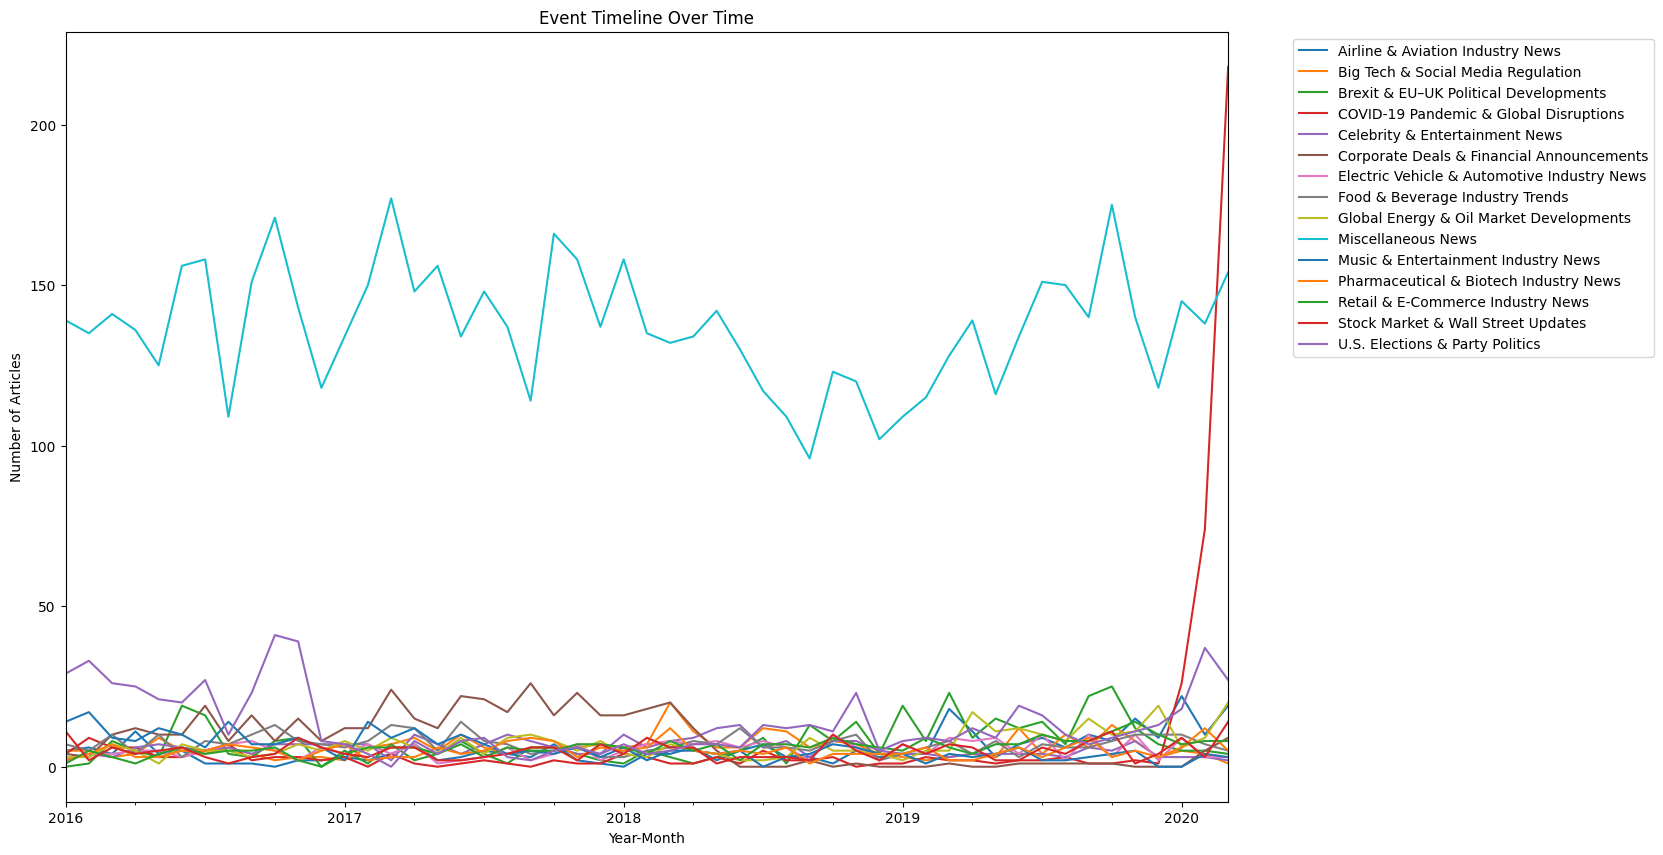

In [143]:
# Plot Timeline
import matplotlib.pyplot as plt

pivot_timeline.plot(figsize=(15,10))

plt.title("Event Timeline Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Number of Articles")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

### What we observe from that flows

##### Which event peaks when

- Political spikes during elections

- Pharma spikes during FDA approvals

- Airline spike during COVID

- Eurozone spikes during crisis

##### Events are distributed.
- Miscellaneous News are dominates highly to all single events in all months
- No single event dominates massively in one month.
- Only COVID (2020) naturally shows a spike.

In [162]:
# Event Peak Detection
timeline.sort_values("article_count", ascending=False).head(10)

,year_month,event_label,article_count
861,2020-03,COVID-19 Pandemic & Global Disruptions,218
252,2017-03,Miscellaneous News,177
787,2019-10,Miscellaneous News,175
165,2016-10,Miscellaneous News,171
373,2017-10,Miscellaneous News,166
426,2018-01,Miscellaneous News,158
391,2017-11,Miscellaneous News,158
114,2016-07,Miscellaneous News,158
97,2016-06,Miscellaneous News,156
286,2017-05,Miscellaneous News,156


The most intense analytical event moments are

- Top peaks = big global events (COVID-19 Pandemic & Global Disruptions	)

- Remaining and Mostly events are miscellaneous single spikes.

### Year-Based Timeline Creation

In [163]:
# Create Year-Based Timeline
df_sample["year"] = df_sample["date"].dt.year

year_timeline = (
    df_sample
    .groupby(["year", "event_label"])
    .size()
    .reset_index(name="count")
    
)

year_timeline

,year,event_label,count
0,2016,Airline & Aviation Industry News,42
1,2016,Big Tech & Social Media Regulation,53
2,2016,Brexit & EU–UK Political Developments,76
3,2016,COVID-19 Pandemic & Global Disruptions,53
4,2016,Celebrity & Entertainment News,64
...,...,...,...
85,2020,Pharmaceutical & Biotech Industry News,23
86,2020,Retail & E-Commerce Industry News,23
87,2020,Stock Market & Wall Street Updates,26
88,2020,U.S. Elections & Party Politics,82


## Step 6:Build a RAG Aplication
#### Monthly Event Summarization (Cost-Efficient Design)

Instead of summarizing full articles, we:

Selected top headlines per month

Used Groq LLM (llama-3.1-8b-instant)

Generated 3–5 line concise summaries

Limited token usage intentionally

In [164]:
# Extract month number
df_sample["month"] = df_sample["date"].dt.month

#### Create Monthly Grouped Table

In [165]:
##Grouped data by (event_label + year + month)
# Now we aggregate:

grouped = (
    df_sample
    .groupby(["event_label", "year", "month"])  # group by event + year + month
    .agg(
        article_count=("title", "count"),       # count articles
        titles=("title", lambda x: list(x))     # collect titles in list
    )
    .reset_index()
)

### Remove Miscellaneous

In [166]:
grouped = grouped[grouped["event_label"] != "Miscellaneous News"]

### Keep Top 5 Events

In [167]:
top_events = (
    grouped.groupby("event_label")["article_count"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

grouped = grouped[grouped["event_label"].isin(top_events)]

### Keep Top 5 Months Per Event

In [168]:

grouped = (
    grouped.sort_values("article_count", ascending=False)
    .groupby("event_label")
    .head(5)
)

In [169]:
grouped.head()

,event_label,year,month,article_count,titles
195,COVID-19 Pandemic & Global Disruptions,2020,3,218,[Soccer: English Premier League suspended due ...
194,COVID-19 Pandemic & Global Disruptions,2020,2,74,[Drone on virus patrol busts Chinese villagers...
785,U.S. Elections & Party Politics,2016,10,41,[There Is Only One Message for Voters to Send ...
786,U.S. Elections & Party Politics,2016,11,39,[GOP holds on to Indiana governorship | TheHil...
824,U.S. Elections & Party Politics,2020,2,37,[Chamber looks to support Democratic allies in...


In [170]:
len(grouped)

25

In [171]:
grouped.shape

(25, 5)

In [172]:
grouped.columns


Index(['event_label', 'year', 'month', 'article_count', 'titles'], dtype='object')

#### Create new empty column for summaries

In [173]:
# Create new empty column for summaries
grouped["monthly_summary"] = None

#### Install & Load LLM

In [174]:
# Install & Load LLM (Using Ollama / Groq API)
!pip install groq -q

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 2.8 MB/s eta 0:00:00a 0:00:01


#### Access Key In Code

In [175]:
# Access Key In Code

import os
from groq import Groq
from kaggle_secrets import UserSecretsClient

# Load my secret key safely
user_secrets = UserSecretsClient()
groq_api_key = user_secrets.get_secret("GROQ_API_KEY")

# Use key
client = Groq(api_key=groq_api_key)

print("Groq client initialized successfully ✅")

Groq client initialized successfully ✅


#### Test with Simple Prompt

In [176]:
# Always test before batch processing.

response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[
        {"role": "user", "content": "Explain Tesla in 2 sentences."}
    ],
    temperature=0.3
)

print(response.choices[0].message.content)

Tesla, Inc. is an American multinational corporation that specializes in electric vehicle (EV) manufacturing, clean energy generation and storage, and energy-related services. Founded in 2003 by Elon Musk, JB Straubel, Martin Eberhard, and Marc Tarpenning, Tesla has become a leading player in the EV market and a pioneer in sustainable energy solutions.


#### Monthly Summary Function

In [177]:
# Now safe production-ready function:
# If any need we can increase the lines

def generate_monthly_summary(event, year, month, titles):
    """
    Generates short 4–5 line monthly event summary. 
    """

    # Limit titles to reduce token usage
    top_titles = titles[:5]

    prompt = f"""
    Event: {event}
    Year: {year}
    Month: {month}

    Headlines:
    {top_titles}

    Summarize in 4 concise sentences.
    Keep under 120 words.
    Focus only on key developments and impact.
    """

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3
    )

    return response.choices[0].message.content

#### Safe Batch Execution (Kaggle Friendly)

In [178]:
import time

BATCH_SIZE = 5   # process only 5 rows at a time (safe for Kaggle)

for start in range(0, len(grouped), BATCH_SIZE):

    end = start + BATCH_SIZE
    print(f"Processing rows {start} to {end}")

    batch = grouped.iloc[start:end]

    for idx in batch.index:

        if pd.isna(grouped.loc[idx, "monthly_summary"]):

            summary = generate_monthly_summary(
                grouped.loc[idx, "event_label"],
                grouped.loc[idx, "year"],
                grouped.loc[idx, "month"],
                grouped.loc[idx, "titles"]
            )

            grouped.loc[idx, "monthly_summary"] = summary
            time.sleep(1)  # prevent rate limit

    # Save checkpoint after every batch
    grouped.to_csv("event_monthly_summary_checkpoint.csv", index=False)

    print("Batch saved successfully ✅")

Processing rows 0 to 5
Batch saved successfully ✅
Processing rows 5 to 10
Batch saved successfully ✅
Processing rows 10 to 15
Batch saved successfully ✅
Processing rows 15 to 20
Batch saved successfully ✅
Processing rows 20 to 25
Batch saved successfully ✅


In [179]:
print("Total monthly event summaries:", len(grouped))

Total monthly event summaries: 25


In [180]:
print("Unique events:", grouped["event_label"].nunique())

Unique events: 5


In [181]:
grouped = grouped.sort_values("article_count", ascending=False)
grouped.head()

,event_label,year,month,article_count,titles,monthly_summary
195,COVID-19 Pandemic & Global Disruptions,2020,3,218,[Soccer: English Premier League suspended due ...,The COVID-19 pandemic led to significant disru...
194,COVID-19 Pandemic & Global Disruptions,2020,2,74,[Drone on virus patrol busts Chinese villagers...,"In February 2020, the COVID-19 pandemic contin..."
785,U.S. Elections & Party Politics,2016,10,41,[There Is Only One Message for Voters to Send ...,"In October 2016, the US presidential election ..."
786,U.S. Elections & Party Politics,2016,11,39,[GOP holds on to Indiana governorship | TheHil...,"In November 2016, the Republican Party maintai..."
824,U.S. Elections & Party Politics,2020,2,37,[Chamber looks to support Democratic allies in...,"In February 2020, the U.S. Chamber of Commerce..."


In [182]:
grouped.to_csv("final_event_summaries.csv", index=False)

## Step 7:Instead of rebuilding FAISS(vectorstore) every time, save it once.

In [183]:
df = pd.read_csv("final_event_summaries.csv")
df.head()

,event_label,year,month,article_count,titles,monthly_summary
0,COVID-19 Pandemic & Global Disruptions,2020,3,218,['Soccer: English Premier League suspended due...,The COVID-19 pandemic led to significant disru...
1,COVID-19 Pandemic & Global Disruptions,2020,2,74,"[""Drone on virus patrol busts Chinese villager...","In February 2020, the COVID-19 pandemic contin..."
2,U.S. Elections & Party Politics,2016,10,41,['There Is Only One Message for Voters to Send...,"In October 2016, the US presidential election ..."
3,U.S. Elections & Party Politics,2016,11,39,['GOP holds on to Indiana governorship | TheHi...,"In November 2016, the Republican Party maintai..."
4,U.S. Elections & Party Politics,2020,2,37,['Chamber looks to support Democratic allies i...,"In February 2020, the U.S. Chamber of Commerce..."


### Create Documents

In [185]:
from langchain.docstore.document import Document

documents = []

for _, row in df.iterrows():
    
    content = f"""
    Event: {row['event_label']}
    Year: {row['year']}
    Month: {row['month']}
    
    Summary:
    {row['monthly_summary']}
    """
    
    documents.append(Document(page_content=content))

### Create Embeddings

In [192]:
! pip install langchain_community

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 9.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.7 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: langchain-text-splitters
    Found existing installation: langchain-text-splitters 0.3.11
    Uninstalling langchain-text-splitters-0.3.11:
      Successfully uninstalled langchain-text-splitters-0.3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.27 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.2.18 which is incompatible.
langchain 0.3.27 requires langchain-text-splitters<1.0.0,>=0.3.9, but you have langchain-text-splitters 1.1.1 which is incompatible.


In [194]:
from langchain.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

/tmp/ipykernel_55/3285295226.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


### Build FAISS

In [196]:
! pip install faiss-cpu

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 56.8 MB/s eta 0:00:00:00:0100:01


In [197]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(documents, embeddings)

### Save FAISS Index 

In [198]:
vectorstore.save_local("faiss_index")

In [200]:
vectorstore